                            OLS Regression Results                            
Dep. Variable:              sea_level   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     3.687
Date:                Wed, 16 Apr 2025   Prob (F-statistic):           6.47e-06
Time:                        16:07:46   Log-Likelihood:                -240.76
No. Observations:                 125   AIC:                             523.5
Df Residuals:                     104   BIC:                             582.9
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -1.01e+04 

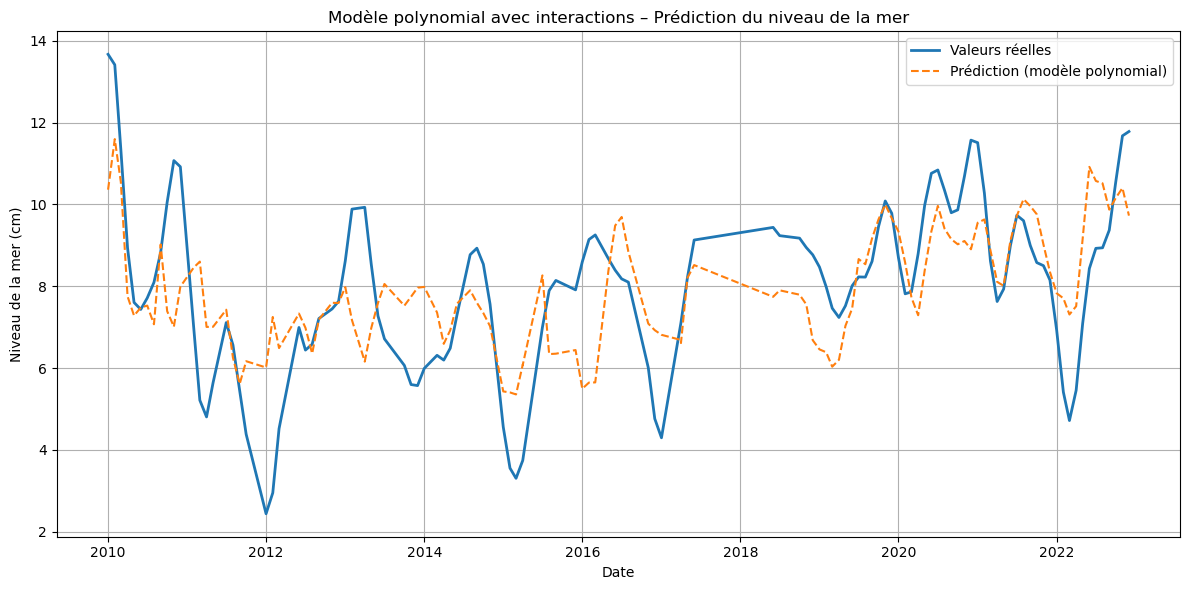

In [1]:
import pandas as pd
import statsmodels.api as sm
import patsy
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('my_data_folder/bdd_utilisable/bdd_rename.csv')

# Nettoyer la date
data['year_month'] = data['year_month'].str.slice(0, 7)
data['year_month'] = pd.to_datetime(data['year_month'], format='%Y-%m')

# Renommer les colonnes pour simplifier (optionnel mais pratique avec statsmodels)
data = data.rename(columns={
    'sea level corrected adjusted': 'sea_level',
    'sst_anomaly_filtered': 'sst',
    'greenland_mass_antarctica': 'ice_mass',
    'chlorophylle': 'chlorophyll',
    'salinité': 'salinity'
})

# Supprimer les lignes incomplètes
data = data.dropna(subset=['sea_level', 'chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity'])

# === Formule du modèle ===
# Interactions + termes quadratiques
formula = 'sea_level ~ (chlorophyll + sst + CO2 + ice_mass + salinity) ** 2 + I(chlorophyll**2) + I(sst**2) + I(CO2**2) + I(ice_mass**2) + I(salinity**2)'

# Créer les matrices X et y
y, X = patsy.dmatrices(formula, data=data, return_type='dataframe')

# Ajuster le modèle
model = sm.OLS(y, X).fit()

# Afficher le résumé
print(model.summary())

# Ajouter les prédictions au DataFrame
data['prediction'] = model.predict(X)

# === Visualisation ===
plt.figure(figsize=(12, 6))
plt.plot(data['year_month'], data['sea_level'], label='Valeurs réelles', linewidth=2)
plt.plot(data['year_month'], data['prediction'], label='Prédiction (modèle polynomial)', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Niveau de la mer (cm)')
plt.title('Modèle polynomial avec interactions – Prédiction du niveau de la mer')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# X = variables explicatives
# y = variable cible
X = data[['chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity']].values
y = data['sea_level'].values

max_degree = 5
for degree in range(1, max_degree + 1):
    poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=5, scoring='r2')
    mean_score = np.mean(scores)

    print(f"Degré {degree} : R² moyen (CV) = {mean_score:.4f}")

Degré 1 : R² moyen (CV) = -0.3121
Degré 2 : R² moyen (CV) = -1.7410
Degré 3 : R² moyen (CV) = -63.0849
Degré 4 : R² moyen (CV) = -106.1188
Degré 5 : R² moyen (CV) = -1148.4327


In [4]:
# Sélection des variables numériques pertinentes
variables = ['sea_level', 'chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity']

# Matrice de corrélation
corr_matrix = data[variables].corr()

# Affichage dans la console
print("Matrice de corrélation :")
print(corr_matrix.round(2)) 

Matrice de corrélation :
             sea_level  chlorophyll   sst   CO2  ice_mass  salinity
sea_level         1.00        -0.13  0.18  0.22     -0.27     -0.16
chlorophyll      -0.13         1.00 -0.14  0.09      0.21      0.63
sst               0.18        -0.14  1.00  0.74     -0.84     -0.14
CO2               0.22         0.09  0.74  1.00     -0.86      0.19
ice_mass         -0.27         0.21 -0.84 -0.86      1.00      0.21
salinity         -0.16         0.63 -0.14  0.19      0.21      1.00


In [5]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# Sélectionner les variables (s'assurer que seules les variables numériques sont prises en compte)
X = data[['chlorophyll', 'sst', 'CO2', 'ice_mass', 'salinity']]  # Variables explicatives
y = data['sea_level']  # Variable cible

# Diviser les données en jeu d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardiser les données (important pour Lasso et Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Appliquer Lasso
lasso = Lasso(alpha=0.1)  # alpha contrôle la régularisation
lasso.fit(X_train_scaled, y_train)

# Appliquer Ridge
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)

# Prédictions avec les deux modèles
lasso_predictions = lasso.predict(X_test_scaled)
ridge_predictions = ridge.predict(X_test_scaled)

# Calculer l'erreur quadratique moyenne (MSE)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)

print(f"Erreur quadratique moyenne (Lasso) : {lasso_mse:.4f}")
print(f"Erreur quadratique moyenne (Ridge) : {ridge_mse:.4f}")

# Afficher les coefficients des modèles
print("Coefficients Lasso:", lasso.coef_)
print("Coefficients Ridge:", ridge.coef_)

Erreur quadratique moyenne (Lasso) : 7.1156
Erreur quadratique moyenne (Ridge) : 7.3493
Coefficients Lasso: [-0.2557005   0.          0.26545555 -0.2691968  -0.27036508]
Coefficients Ridge: [-0.31857922 -0.17666952  0.5767591  -0.18862894 -0.4239958 ]
